# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

## 1. Imports & Configuration

In [1]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import lightgbm as lgb
# import xgboost as xgb    # Uncomment if using XGBoost
# import catboost as cb     # Uncomment if using CatBoost

# Counterfactual Explanation packages
import dice_ml
# import alibi               # Uncomment when implementing Alibi

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile
import gc 
from sklearn.feature_selection import VarianceThreshold
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
import shap
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\Users\konra\wut-counterfactual-explanations\data
Models directory: C:\Users\konra\wut-counterfactual-explanations\models


## 2. Data Loading & Initial EDA

Make sure you have downloaded the data from Kaggle into the `data/` directory.
See the README for download instructions.

In [2]:
# Download the dataset using Kaggle API
kaggle_dataset = "home-credit-default-risk"
output_dir = DATA_DIR

output_dir.mkdir(parents=True, exist_ok=True)

subprocess.run(
    ["kaggle", "competitions", "download", "-c", kaggle_dataset, "-p", str(output_dir)],
    check=True,
)

# Unzip the downloaded archive

zip_path = output_dir / f"{kaggle_dataset}.zip"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(output_dir)

zip_path.unlink()
print(f"Data downloaded and extracted to {output_dir}")

CalledProcessError: Command '['kaggle', 'competitions', 'download', '-c', 'home-credit-default-risk', '-p', 'C:\\Users\\konra\\wut-counterfactual-explanations\\data']' returned non-zero exit status 1.

In [2]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")

print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")
app_train.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Quick overview of missing values
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

Columns with >50% missing:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG      

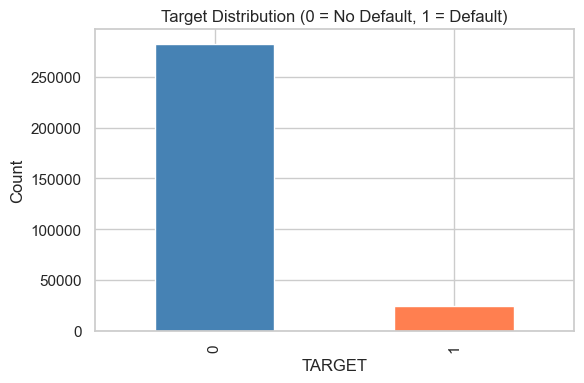

In [4]:
# Target distribution visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
app_train[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Distribution (0 = No Default, 1 = Default)")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Create new features with **semantic, human-readable names**.

Example naming conventions:
- `income_to_credit_ratio` (not `feat_001`)
- `annuity_to_income_ratio` (not `ratio_2`)
- `bureau_active_credits_count` (not `bur_cnt`)

In [5]:
# TODO: Load and aggregate supplementary data sources
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")
previous_app = pd.read_csv(DATA_DIR / "previous_application.csv")
pos_cash = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
credit_card = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

In [6]:
# --- Example feature engineering (extend this!) ---
df = app_train.copy()

# Ratio features (semantic names)
df["INCOME_TO_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"].replace(0, np.nan)
df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
df["CREDIT_TO_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]

# External source aggregation
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXTERNAL_SOURCES_MEAN"] = df[ext_cols].mean(axis=1)
df["EXTERNAL_SOURCES_STD"] = df[ext_cols].std(axis=1)

# TODO: Add other aggregates


In [7]:
# Dochód na jedna osobe
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)
# Sotsunek liczby dzieci na rodzine
df['CHILDREN_RATIO'] = df['CNT_CHILDREN'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)
# Stosunek wielkości kredytu do ceny towaru
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
contact_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
df['CONTACT_INFO_COUNT'] = df[contact_cols].sum(axis=1)


### Tabelka pos_cash

In [8]:
pos_cash.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [9]:
pos_cash["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Active                   9151119
Completed                 744883
Signed                     87260
Demand                      7065
Returned to the store       5461
Approved                    4917
Amortized debt               636
Canceled                      15
XNA                            2
Name: count, dtype: int64

In [10]:
pos_cash["is_active"] = (pos_cash["NAME_CONTRACT_STATUS"] == "Active").astype(int)
pos_cash = pos_cash.drop(columns=["NAME_CONTRACT_STATUS"])

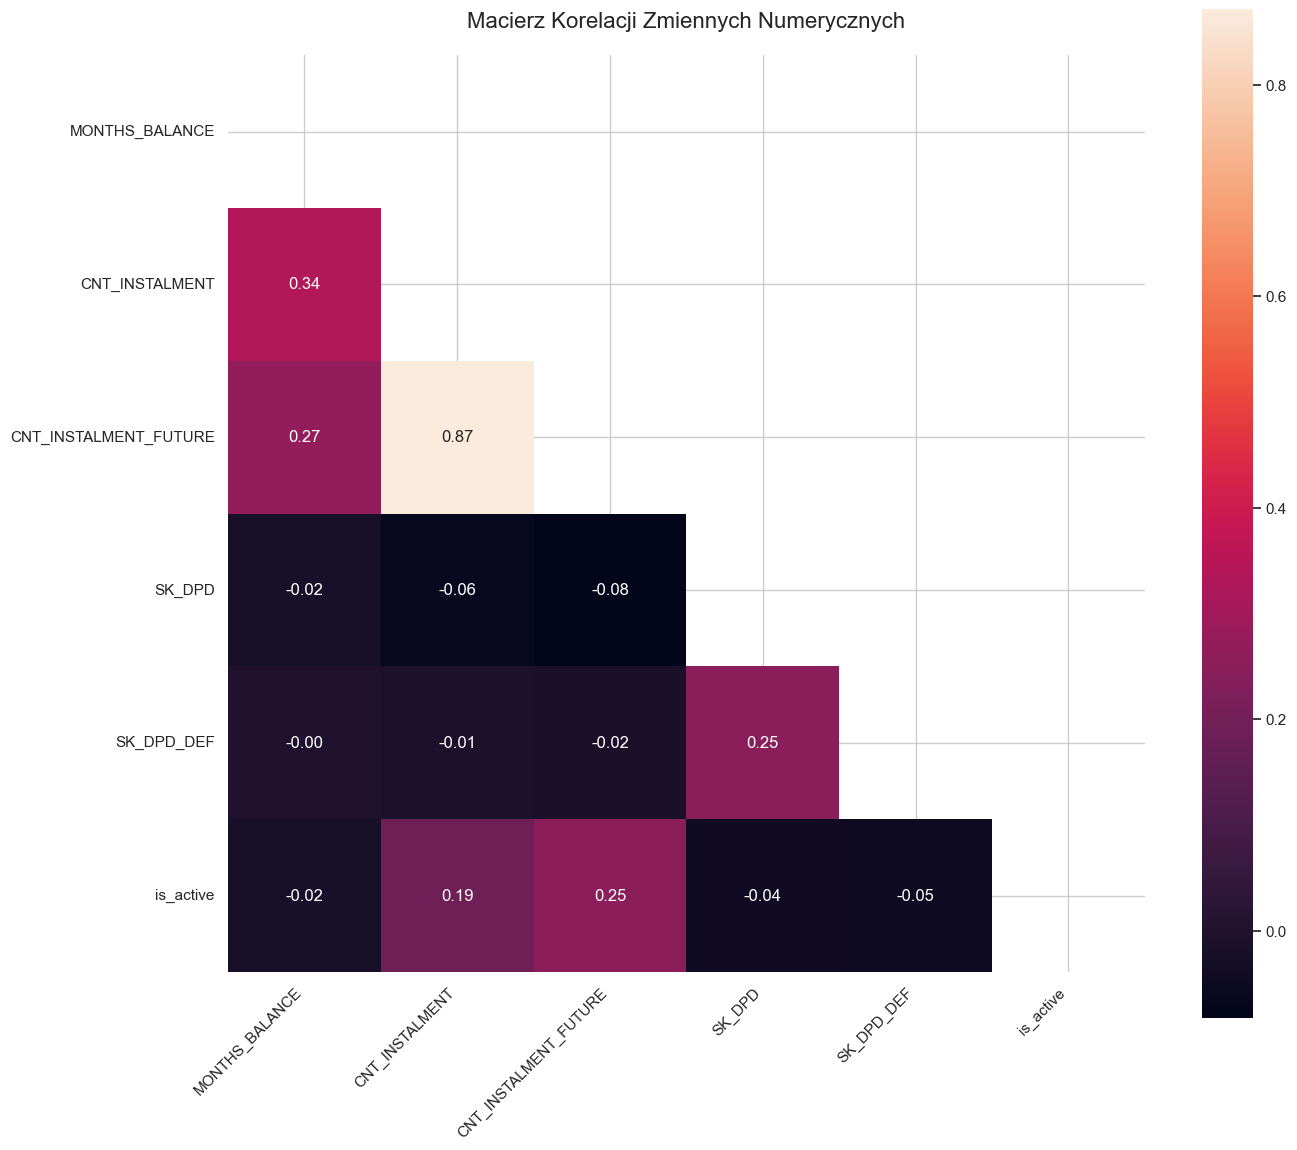

In [11]:
# Teraz zajmujemy się zmiennymi numerycznymi. Część z nich może być ze sobą mocno skorelowana więc tworzymy macierz korelacji

corr_matrix = pos_cash.drop(columns=["SK_ID_PREV", "SK_ID_CURR"]).corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Rysowanie mapy cieplnej
sns.heatmap(corr_matrix, 
            mask=mask,              
            annot=True,              
            fmt=".2f",                           
            square=True,            
           )          
            

plt.title('Macierz Korelacji Zmiennych Numerycznych', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [12]:
POS_CASH_balance_agg = pos_cash.groupby("SK_ID_PREV").agg(
    POS_CASH_balance_count=("SK_ID_PREV", "count"),
    POS_CASH_balance_MONTHS_BALANCE_min =("MONTHS_BALANCE", "min"),
    POS_CASH_balance_MONTHS_BALANCE_max =("MONTHS_BALANCE", "max"),
    POS_CASH_balance_MONTHS_BALANCE_mean =("MONTHS_BALANCE", "mean"),
    POS_CASH_balance_CNT_INSTALMENT_min =("CNT_INSTALMENT", "min"),
    POS_CASH_balance_CNT_INSTALMENT_max =("CNT_INSTALMENT", "max"),
    POS_CASH_balance_CNT_INSTALMENT_mean =("CNT_INSTALMENT", "mean"),
    POS_CASH_balance_CNT_INSTALMENT_sum =("CNT_INSTALMENT", "sum"),
    POS_CASH_balance_CNT_INSTALMENT_FUTURE_min =("CNT_INSTALMENT_FUTURE", "min"),
    POS_CASH_balance_CNT_INSTALMENT_FUTURE_max =("CNT_INSTALMENT_FUTURE", "max"),
    POS_CASH_balance_CNT_INSTALMENT_FUTURE_mean =("CNT_INSTALMENT_FUTURE", "mean"),
    POS_CASH_balance_CNT_INSTALMENT_FUTURE_sum =("CNT_INSTALMENT_FUTURE", "sum"),
    POS_CASH_balance_SK_DPD_min =("SK_DPD", "min"),
    POS_CASH_balance_SK_DPD_max =("SK_DPD", "max"),
    POS_CASH_balance_SK_DPD_mean =("SK_DPD", "mean"),
    POS_CASH_balance_SK_DPD_DEF_min =("SK_DPD_DEF", "min"),
    POS_CASH_balance_SK_DPD_DEF_max =("SK_DPD_DEF", "max"),
    POS_CASH_balance_SK_DPD_DEF_mean =("SK_DPD_DEF", "mean"),
    POS_CASH_balance_is_active_sum =("is_active","sum")
).reset_index()
POS_CASH_balance_agg.head()

,SK_ID_PREV,POS_CASH_balance_count,POS_CASH_balance_MONTHS_BALANCE_min,POS_CASH_balance_MONTHS_BALANCE_max,POS_CASH_balance_MONTHS_BALANCE_mean,POS_CASH_balance_CNT_INSTALMENT_min,POS_CASH_balance_CNT_INSTALMENT_max,POS_CASH_balance_CNT_INSTALMENT_mean,POS_CASH_balance_CNT_INSTALMENT_sum,POS_CASH_balance_CNT_INSTALMENT_FUTURE_min,POS_CASH_balance_CNT_INSTALMENT_FUTURE_max,POS_CASH_balance_CNT_INSTALMENT_FUTURE_mean,POS_CASH_balance_CNT_INSTALMENT_FUTURE_sum,POS_CASH_balance_SK_DPD_min,POS_CASH_balance_SK_DPD_max,POS_CASH_balance_SK_DPD_mean,POS_CASH_balance_SK_DPD_DEF_min,POS_CASH_balance_SK_DPD_DEF_max,POS_CASH_balance_SK_DPD_DEF_mean,POS_CASH_balance_is_active_sum
0,1000001,3,-10,-8,-9.0,2.0,12.0,8.666667,26.0,0.0,12.0,7.666667,23.0,0,0,0.0,0,0,0.0,2
1,1000002,5,-54,-50,-52.0,4.0,6.0,5.200000,26.0,0.0,4.0,2.000000,10.0,0,0,0.0,0,0,0.0,4
2,1000003,4,-4,-1,-2.5,12.0,12.0,12.000000,48.0,9.0,12.0,10.500000,42.0,0,0,0.0,0,0,0.0,4
3,1000004,8,-29,-22,-25.5,7.0,10.0,9.625000,77.0,0.0,10.0,6.125000,49.0,0,0,0.0,0,0,0.0,7
4,1000005,11,-56,-46,-51.0,10.0,10.0,10.000000,110.0,0.0,10.0,5.000000,55.0,0,0,0.0,0,0,0.0,10


### Tabelka installments

In [13]:
installments.head()
missing_pct = (installments.isnull().sum() / len(installments) * 100).sort_values(ascending=False)
print(f"Columns with > 0% missing:\n{missing_pct[missing_pct > 0]}")

Columns with > 0% missing:
DAYS_ENTRY_PAYMENT    0.021352
AMT_PAYMENT           0.021352
dtype: float64


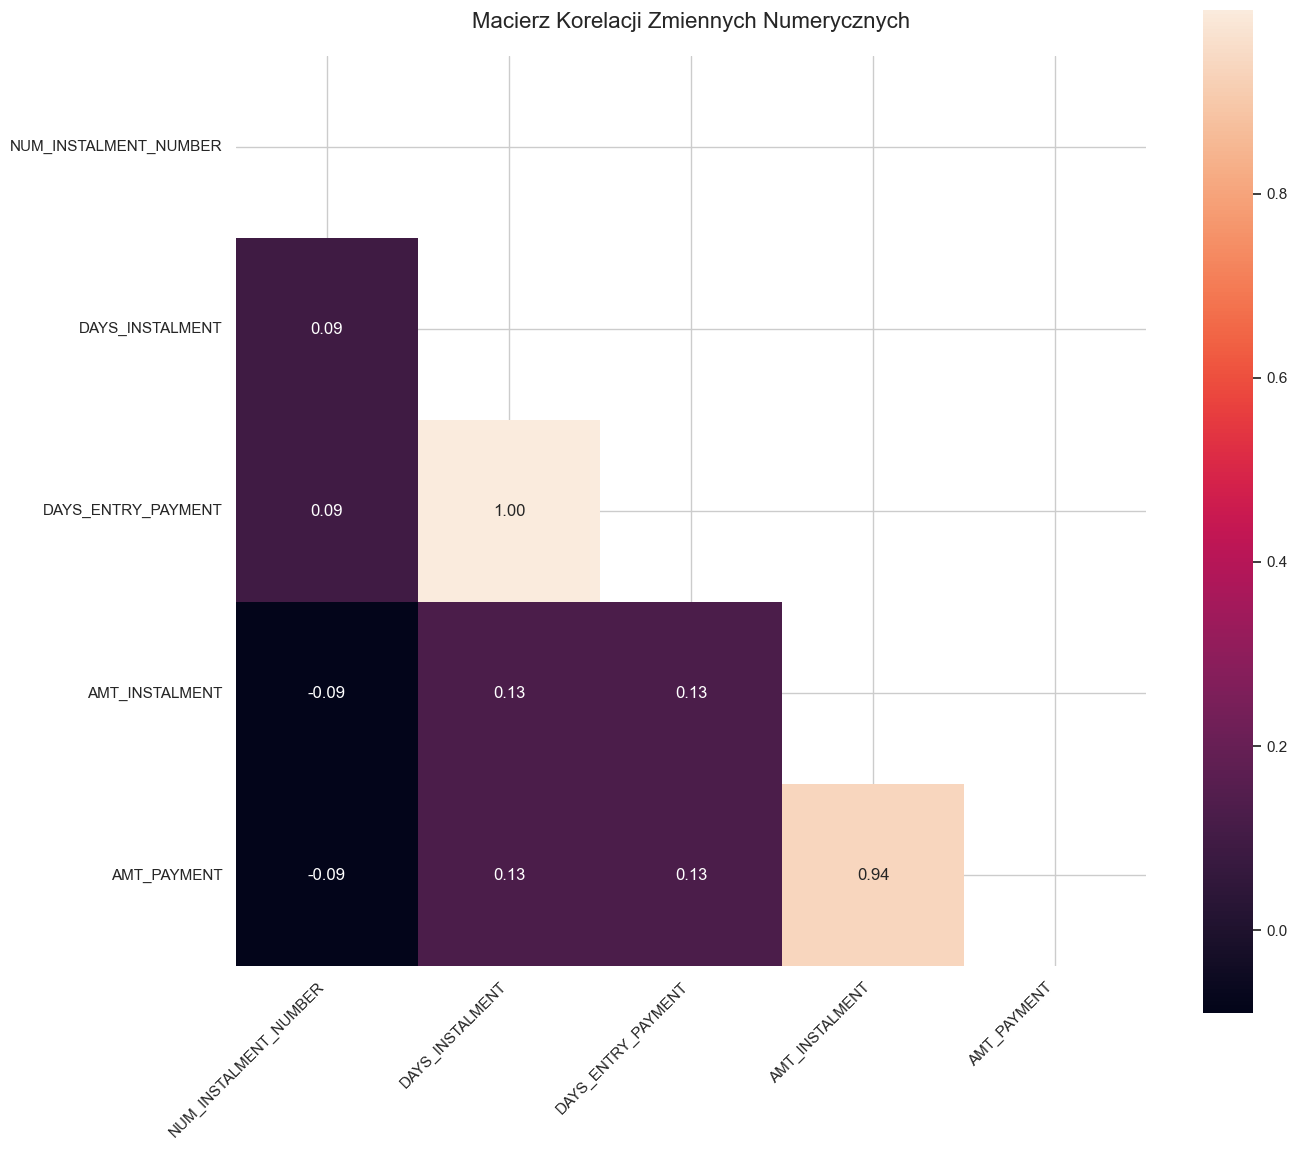

In [14]:
# Teraz zajmujemy się zmiennymi numerycznymi. Część z nich może być ze sobą mocno skorelowana więc tworzymy macierz korelacji

corr_matrix = installments.drop(columns=["SK_ID_PREV", "SK_ID_CURR", "NUM_INSTALMENT_VERSION"]).corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Rysowanie mapy cieplnej
sns.heatmap(corr_matrix, 
            mask=mask,              
            annot=True,              
            fmt=".2f",                           
            square=True,            
           )          
            

plt.title('Macierz Korelacji Zmiennych Numerycznych', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [15]:
installments = installments.drop(columns=["DAYS_ENTRY_PAYMENT", "AMT_PAYMENT"])

In [16]:
installments_payments_agg = installments.groupby("SK_ID_PREV").agg(
    installments_payments_count=("SK_ID_PREV", "count"),
    installments_payments_NUM_INSTALMENT_NUMBER_min =("NUM_INSTALMENT_NUMBER", "min"),
    installments_payments_NUM_INSTALMENT_NUMBER_max =("NUM_INSTALMENT_NUMBER", "max"),
    installments_payments_NUM_INSTALMENT_NUMBER_mean =("NUM_INSTALMENT_NUMBER", "mean"),
    installments_payments_DAYS_INSTALMENT_min =("DAYS_INSTALMENT", "min"),
    installments_payments_DAYS_INSTALMENT_max =("DAYS_INSTALMENT", "max"),
    installments_payments_DAYS_INSTALMENT_mean =("DAYS_INSTALMENT", "mean"),
    installments_payments_AMT_INSTALMENT_min =("AMT_INSTALMENT", "min"),
    installments_payments_AMT_INSTALMENT_max =("AMT_INSTALMENT", "max"),
    installments_payments_AMT_INSTALMENT_mean =("AMT_INSTALMENT", "mean"),
    installments_payments_AMT_INSTALMENT_sum =("AMT_INSTALMENT", "sum"),
).reset_index()

### Tabelka credit_card

In [17]:
missing_pct = (credit_card.isnull().sum() / len(credit_card) * 100).sort_values(ascending=False)
print(f"Columns with > 0% missing:\n{missing_pct[missing_pct > 0]}")

Columns with > 0% missing:
AMT_PAYMENT_CURRENT           19.998063
AMT_DRAWINGS_ATM_CURRENT      19.524872
CNT_DRAWINGS_POS_CURRENT      19.524872
AMT_DRAWINGS_OTHER_CURRENT    19.524872
AMT_DRAWINGS_POS_CURRENT      19.524872
CNT_DRAWINGS_OTHER_CURRENT    19.524872
CNT_DRAWINGS_ATM_CURRENT      19.524872
CNT_INSTALMENT_MATURE_CUM      7.948208
AMT_INST_MIN_REGULARITY        7.948208
dtype: float64


In [18]:
credit_card["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Active           3698436
Completed         128918
Signed             11058
Demand              1365
Sent proposal        513
Refused               17
Approved               5
Name: count, dtype: int64

In [19]:
credit_card["is_active"] = (credit_card["NAME_CONTRACT_STATUS"] == "Active").astype(int)
credit_card = credit_card.drop(columns=["NAME_CONTRACT_STATUS"])

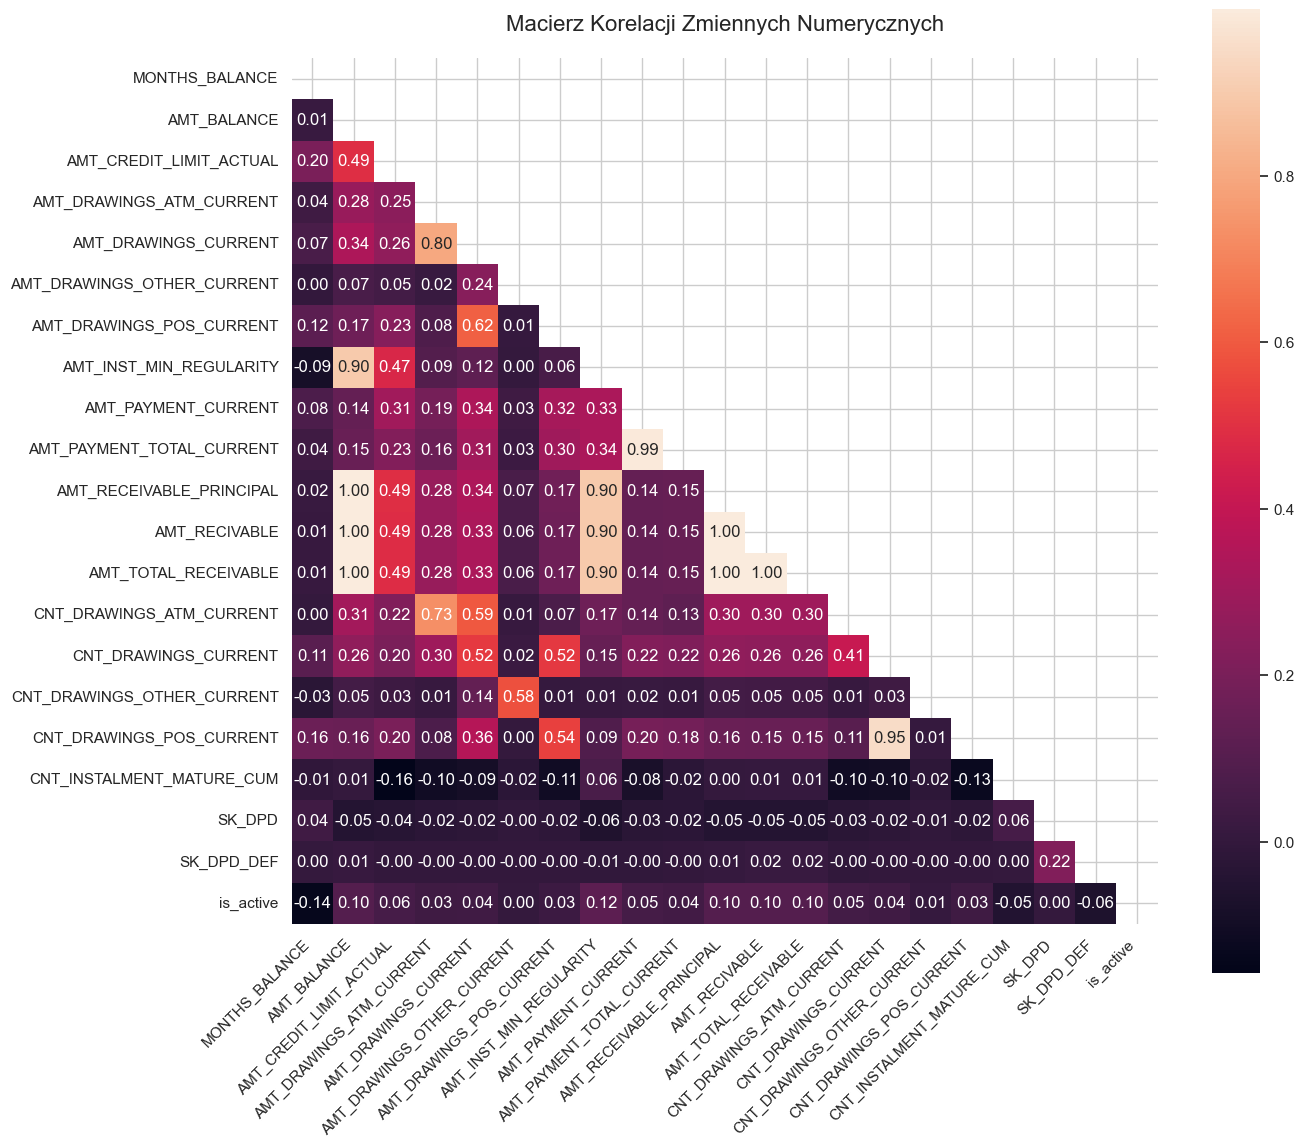

In [20]:
# Teraz zajmujemy się zmiennymi numerycznymi. Część z nich może być ze sobą mocno skorelowana więc tworzymy macierz korelacji

corr_matrix = credit_card.drop(columns=["SK_ID_PREV", "SK_ID_CURR"]).corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Rysowanie mapy cieplnej
sns.heatmap(corr_matrix, 
            mask=mask,              
            annot=True,              
            fmt=".2f",                           
            square=True,            
           )          
            

plt.title('Macierz Korelacji Zmiennych Numerycznych', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [21]:
credit_card = credit_card.drop(columns=["AMT_RECEIVABLE_PRINCIPAL", "AMT_RECIVABLE", "AMT_TOTAL_RECEIVABLE", 
                                                        "AMT_PAYMENT_TOTAL_CURRENT", "CNT_DRAWINGS_OTHER_CURRENT", "CNT_DRAWINGS_POS_CURRENT",
                                                        "AMT_INST_MIN_REGULARITY"])

In [22]:
credit_card_balance_agg = credit_card.groupby("SK_ID_PREV").agg(
    credit_card_balance_count=("SK_ID_PREV", "count"),
    credit_card_balance_MONTHS_BALANCE_min =("MONTHS_BALANCE", "min"),
    credit_card_balance_MONTHS_BALANCE_max =("MONTHS_BALANCE", "max"),
    credit_card_balance_MONTHS_BALANCE_mean =("MONTHS_BALANCE", "mean"),
    credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_min =("AMT_CREDIT_LIMIT_ACTUAL", "min"),
    credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_max =("AMT_CREDIT_LIMIT_ACTUAL", "max"),
    credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_mean =("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_min =("AMT_DRAWINGS_ATM_CURRENT", "min"),
    credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_max =("AMT_DRAWINGS_ATM_CURRENT", "max"),
    credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_mean =("AMT_DRAWINGS_ATM_CURRENT", "mean"),
    credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_sum =("AMT_DRAWINGS_ATM_CURRENT", "sum"),
    credit_card_balance_AMT_DRAWINGS_CURRENT_min =("AMT_DRAWINGS_CURRENT", "min"),
    credit_card_balance_AMT_DRAWINGS_CURRENT_max =("AMT_DRAWINGS_CURRENT", "max"),
    credit_card_balance_AMT_DRAWINGS_CURRENT_mean =("AMT_DRAWINGS_CURRENT", "mean"),
    credit_card_balance_AMT_DRAWINGS_CURRENT_sum =("AMT_DRAWINGS_CURRENT", "sum"),
    credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_min =("AMT_DRAWINGS_OTHER_CURRENT", "min"),
    credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_max =("AMT_DRAWINGS_OTHER_CURRENT", "max"),
    credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_mean =("AMT_DRAWINGS_OTHER_CURRENT", "mean"),
    credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_sum =("AMT_DRAWINGS_OTHER_CURRENT", "sum"),
    credit_card_balance_AMT_DRAWINGS_POS_CURRENT_min =("AMT_DRAWINGS_POS_CURRENT", "min"),
    credit_card_balance_AMT_DRAWINGS_POS_CURRENT_max =("AMT_DRAWINGS_POS_CURRENT", "max"),
    credit_card_balance_AMT_DRAWINGS_POS_CURRENT_mean =("AMT_DRAWINGS_POS_CURRENT", "mean"),
    credit_card_balance_AMT_DRAWINGS_POS_CURRENT_sum =("AMT_DRAWINGS_POS_CURRENT", "sum"),
    credit_card_balance_AMT_PAYMENT_CURRENT_min =("AMT_PAYMENT_CURRENT", "min"),
    credit_card_balance_AMT_PAYMENT_CURRENT_max =("AMT_PAYMENT_CURRENT", "max"),
    credit_card_balance_AMT_PAYMENT_CURRENT_mean =("AMT_PAYMENT_CURRENT", "mean"),
    credit_card_balance_AMT_PAYMENT_CURRENT_sum =("AMT_PAYMENT_CURRENT", "sum"),
    credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_min =("CNT_DRAWINGS_ATM_CURRENT", "min"),
    credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_max =("CNT_DRAWINGS_ATM_CURRENT", "max"),
    credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_mean =("CNT_DRAWINGS_ATM_CURRENT", "mean"),
    credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_sum =("CNT_DRAWINGS_ATM_CURRENT", "mean"),
    credit_card_balance_CNT_DRAWINGS_CURRENT_min =("CNT_DRAWINGS_CURRENT", "min"),
    credit_card_balance_CNT_DRAWINGS_CURRENT_max =("CNT_DRAWINGS_CURRENT", "max"),
    credit_card_balance_CNT_DRAWINGS_CURRENT_mean =("CNT_DRAWINGS_CURRENT", "mean"),
    credit_card_balance_CNT_DRAWINGS_CURRENT_sum =("CNT_DRAWINGS_CURRENT", "sum"),
    credit_card_balance_CNT_INSTALMENT_MATURE_CUM_min =("CNT_INSTALMENT_MATURE_CUM", "min"),
    credit_card_balance_CNT_INSTALMENT_MATURE_CUM_max =("CNT_INSTALMENT_MATURE_CUM", "max"),
    credit_card_balance_CNT_INSTALMENT_MATURE_CUM_mean =("CNT_INSTALMENT_MATURE_CUM", "mean"),
    credit_card_balance_CNT_INSTALMENT_MATURE_CUM_sum =("CNT_INSTALMENT_MATURE_CUM", "sum"),
    credit_card_balance_SK_DPD_min =("SK_DPD", "min"),
    credit_card_balance_SK_DPD_max =("SK_DPD", "max"),
    credit_card_balance_SK_DPD_mean =("SK_DPD", "mean"),
    credit_card_balance_SK_DPD_DEF_min =("SK_DPD_DEF", "min"),
    credit_card_balance_SK_DPD_DEF_max =("SK_DPD_DEF", "max"),
    credit_card_balance_SK_DPD_DEF_mean =("SK_DPD_DEF", "mean"),
    credit_card_balance_is_active_sum =("is_active","sum")
).reset_index()

### Tabelka previous_app

In [23]:
previous_app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

In [24]:
previous_app = previous_app.drop(columns=['WEEKDAY_APPR_PROCESS_START'])

In [25]:
previous_app = pd.get_dummies(previous_app)

In [26]:
missing_pct = (previous_app.isnull().sum() / len(previous_app) * 100).sort_values(ascending=False)
print(f"Columns with > 0% missing:\n{missing_pct[missing_pct > 0]}")

Columns with > 0% missing:
RATE_INTEREST_PRIVILEGED     99.643698
RATE_INTEREST_PRIMARY        99.643698
RATE_DOWN_PAYMENT            53.636480
AMT_DOWN_PAYMENT             53.636480
NFLAG_INSURED_ON_APPROVAL    40.298129
DAYS_TERMINATION             40.298129
DAYS_LAST_DUE                40.298129
DAYS_LAST_DUE_1ST_VERSION    40.298129
DAYS_FIRST_DUE               40.298129
DAYS_FIRST_DRAWING           40.298129
AMT_GOODS_PRICE              23.081773
AMT_ANNUITY                  22.286665
CNT_PAYMENT                  22.286366
AMT_CREDIT                    0.000060
dtype: float64


In [27]:
previous_app = previous_app.drop(columns=["RATE_INTEREST_PRIVILEGED", "RATE_INTEREST_PRIMARY"])

In [28]:
df2 = previous_app.merge(POS_CASH_balance_agg, on="SK_ID_PREV", how = "left")
df2 = df2.merge(installments_payments_agg, on="SK_ID_PREV", how = "left")
df2 = df2.merge(credit_card_balance_agg, on="SK_ID_PREV", how = "left")

In [29]:
missing_pct = (df2.isnull().sum() / len(df2) * 100).sort_values(ascending=False)
print(f"Columns with > 0% missing:\n{missing_pct[missing_pct > 0]}")

Columns with > 0% missing:
credit_card_balance_AMT_PAYMENT_CURRENT_max          96.280117
credit_card_balance_AMT_PAYMENT_CURRENT_mean         96.280117
credit_card_balance_AMT_PAYMENT_CURRENT_min          96.280117
credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_min     96.275387
credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_mean    96.275387
                                                       ...    
DAYS_FIRST_DUE                                       40.298129
AMT_GOODS_PRICE                                      23.081773
AMT_ANNUITY                                          22.286665
CNT_PAYMENT                                          22.286366
AMT_CREDIT                                            0.000060
Length: 88, dtype: float64


In [30]:
df2.head()

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,...,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_max,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_mean,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_sum,credit_card_balance_SK_DPD_min,credit_card_balance_SK_DPD_max,credit_card_balance_SK_DPD_mean,credit_card_balance_SK_DPD_DEF_min,credit_card_balance_SK_DPD_DEF_max,credit_card_balance_SK_DPD_DEF_mean,credit_card_balance_is_active_sum
0,2030495,271877,1730.430,17145.0,17145.0,0.0,17145.0,15,1,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2802425,108129,25188.615,607500.0,679671.0,NaN,607500.0,11,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2523466,122040,15060.735,112500.0,136444.5,NaN,112500.0,11,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2819243,176158,47041.335,450000.0,470790.0,NaN,450000.0,7,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1784265,202054,31924.395,337500.0,404055.0,NaN,337500.0,9,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Tworzymy słownik dla agregatów konkretnych kolumn 
aggregations = {
 'AMT_ANNUITY': ['min', 'mean', 'max'],
 'AMT_APPLICATION': ['min', 'mean', 'max'],
 'AMT_CREDIT': ['min', 'mean', 'max'],
 'AMT_DOWN_PAYMENT': ['min', 'mean', 'max'],
 'AMT_GOODS_PRICE': ['min', 'mean', 'max'],
 'HOUR_APPR_PROCESS_START': ['min', 'mean', 'max'],
 'NFLAG_LAST_APPL_IN_DAY': ['min', 'mean', 'max'],
 'RATE_DOWN_PAYMENT': ['min', 'mean', 'max'],
 'DAYS_DECISION': ['min', 'mean', 'max'],
 'SELLERPLACE_AREA': ['min', 'mean', 'max'],
 'CNT_PAYMENT': ['min', 'mean', 'max'],
 'DAYS_FIRST_DRAWING': ['min', 'mean', 'max'],
 'DAYS_FIRST_DUE': ['min', 'mean', 'max'],
 'DAYS_LAST_DUE_1ST_VERSION': ['min', 'mean', 'max'],
 'DAYS_LAST_DUE': ['min', 'mean', 'max'],
 'DAYS_TERMINATION': ['min', 'mean', 'max'],
 'NFLAG_INSURED_ON_APPROVAL': ['min', 'mean', 'max'],
 'NAME_CONTRACT_TYPE_Cash loans': ['sum'],
 'NAME_CONTRACT_TYPE_Consumer loans': ['sum'],
 'NAME_CONTRACT_TYPE_Revolving loans': ['sum'],
 'NAME_CONTRACT_TYPE_XNA': ['sum'],
 'FLAG_LAST_APPL_PER_CONTRACT_N': ['sum'],
 'FLAG_LAST_APPL_PER_CONTRACT_Y': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Building a house or an annex': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Business development': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a garage': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a holiday home / land': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a home': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a new car': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Buying a used car': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Car repairs': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Education': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Everyday expenses': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Furniture': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Gasification / water supply': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Hobby': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Journey': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Medicine': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Money for a third person': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Other': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Payments on other loans': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Purchase of electronic equipment': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Refusal to name the goal': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Repairs': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Urgent needs': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_Wedding / gift / holiday': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_XAP': ['sum'],
 'NAME_CASH_LOAN_PURPOSE_XNA': ['sum'],
 'NAME_CONTRACT_STATUS_Approved': ['sum'],
 'NAME_CONTRACT_STATUS_Canceled': ['sum'],
 'NAME_CONTRACT_STATUS_Refused': ['sum'],
 'NAME_CONTRACT_STATUS_Unused offer': ['sum'],
 'NAME_PAYMENT_TYPE_Cash through the bank': ['sum'],
 'NAME_PAYMENT_TYPE_Cashless from the account of the employer': ['sum'],
 'NAME_PAYMENT_TYPE_Non-cash from your account': ['sum'],
 'NAME_PAYMENT_TYPE_XNA': ['sum'],
 'CODE_REJECT_REASON_CLIENT': ['sum'],
 'CODE_REJECT_REASON_HC': ['sum'],
 'CODE_REJECT_REASON_LIMIT': ['sum'],
 'CODE_REJECT_REASON_SCO': ['sum'],
 'CODE_REJECT_REASON_SCOFR': ['sum'],
 'CODE_REJECT_REASON_SYSTEM': ['sum'],
 'CODE_REJECT_REASON_VERIF': ['sum'],
 'CODE_REJECT_REASON_XAP': ['sum'],
 'CODE_REJECT_REASON_XNA': ['sum'],
 'NAME_TYPE_SUITE_Children': ['sum'],
 'NAME_TYPE_SUITE_Family': ['sum'],
 'NAME_TYPE_SUITE_Group of people': ['sum'],
 'NAME_TYPE_SUITE_Other_A': ['sum'],
 'NAME_TYPE_SUITE_Other_B': ['sum'],
 'NAME_TYPE_SUITE_Spouse, partner': ['sum'],
 'NAME_TYPE_SUITE_Unaccompanied': ['sum'],
 'NAME_CLIENT_TYPE_New': ['sum'],
 'NAME_CLIENT_TYPE_Refreshed': ['sum'],
 'NAME_CLIENT_TYPE_Repeater': ['sum'],
 'NAME_CLIENT_TYPE_XNA': ['sum'],
 'NAME_GOODS_CATEGORY_Additional Service': ['sum'],
 'NAME_GOODS_CATEGORY_Animals': ['sum'],
 'NAME_GOODS_CATEGORY_Audio/Video': ['sum'],
 'NAME_GOODS_CATEGORY_Auto Accessories': ['sum'],
 'NAME_GOODS_CATEGORY_Clothing and Accessories': ['sum'],
 'NAME_GOODS_CATEGORY_Computers': ['sum'],
 'NAME_GOODS_CATEGORY_Construction Materials': ['sum'],
 'NAME_GOODS_CATEGORY_Consumer Electronics': ['sum'],
 'NAME_GOODS_CATEGORY_Direct Sales': ['sum'],
 'NAME_GOODS_CATEGORY_Education': ['sum'],
 'NAME_GOODS_CATEGORY_Fitness': ['sum'],
 'NAME_GOODS_CATEGORY_Furniture': ['sum'],
 'NAME_GOODS_CATEGORY_Gardening': ['sum'],
 'NAME_GOODS_CATEGORY_Homewares': ['sum'],
 'NAME_GOODS_CATEGORY_House Construction': ['sum'],
 'NAME_GOODS_CATEGORY_Insurance': ['sum'],
 'NAME_GOODS_CATEGORY_Jewelry': ['sum'],
 'NAME_GOODS_CATEGORY_Medical Supplies': ['sum'],
 'NAME_GOODS_CATEGORY_Medicine': ['sum'],
 'NAME_GOODS_CATEGORY_Mobile': ['sum'],
 'NAME_GOODS_CATEGORY_Office Appliances': ['sum'],
 'NAME_GOODS_CATEGORY_Other': ['sum'],
 'NAME_GOODS_CATEGORY_Photo / Cinema Equipment': ['sum'],
 'NAME_GOODS_CATEGORY_Sport and Leisure': ['sum'],
 'NAME_GOODS_CATEGORY_Tourism': ['sum'],
 'NAME_GOODS_CATEGORY_Vehicles': ['sum'],
 'NAME_GOODS_CATEGORY_Weapon': ['sum'],
 'NAME_GOODS_CATEGORY_XNA': ['sum'],
 'NAME_PORTFOLIO_Cards': ['sum'],
 'NAME_PORTFOLIO_Cars': ['sum'],
 'NAME_PORTFOLIO_Cash': ['sum'],
 'NAME_PORTFOLIO_POS': ['sum'],
 'NAME_PORTFOLIO_XNA': ['sum'],
 'NAME_PRODUCT_TYPE_XNA': ['sum'],
 'NAME_PRODUCT_TYPE_walk-in': ['sum'],
 'NAME_PRODUCT_TYPE_x-sell': ['sum'],
 'CHANNEL_TYPE_AP+ (Cash loan)': ['sum'],
 'CHANNEL_TYPE_Car dealer': ['sum'],
 'CHANNEL_TYPE_Channel of corporate sales': ['sum'],
 'CHANNEL_TYPE_Contact center': ['sum'],
 'CHANNEL_TYPE_Country-wide': ['sum'],
 'CHANNEL_TYPE_Credit and cash offices': ['sum'],
 'CHANNEL_TYPE_Regional / Local': ['sum'],
 'CHANNEL_TYPE_Stone': ['sum'],
 'NAME_SELLER_INDUSTRY_Auto technology': ['sum'],
 'NAME_SELLER_INDUSTRY_Clothing': ['sum'],
 'NAME_SELLER_INDUSTRY_Connectivity': ['sum'],
 'NAME_SELLER_INDUSTRY_Construction': ['sum'],
 'NAME_SELLER_INDUSTRY_Consumer electronics': ['sum'],
 'NAME_SELLER_INDUSTRY_Furniture': ['sum'],
 'NAME_SELLER_INDUSTRY_Industry': ['sum'],
 'NAME_SELLER_INDUSTRY_Jewelry': ['sum'],
 'NAME_SELLER_INDUSTRY_MLM partners': ['sum'],
 'NAME_SELLER_INDUSTRY_Tourism': ['sum'],
 'NAME_SELLER_INDUSTRY_XNA': ['sum'],
 'NAME_YIELD_GROUP_XNA': ['sum'],
 'NAME_YIELD_GROUP_high': ['sum'],
 'NAME_YIELD_GROUP_low_action': ['sum'],
 'NAME_YIELD_GROUP_low_normal': ['sum'],
 'NAME_YIELD_GROUP_middle': ['sum'],
 'PRODUCT_COMBINATION_Card Street': ['sum'],
 'PRODUCT_COMBINATION_Card X-Sell': ['sum'],
 'PRODUCT_COMBINATION_Cash': ['sum'],
 'PRODUCT_COMBINATION_Cash Street: high': ['sum'],
 'PRODUCT_COMBINATION_Cash Street: low': ['sum'],
 'PRODUCT_COMBINATION_Cash Street: middle': ['sum'],
 'PRODUCT_COMBINATION_Cash X-Sell: high': ['sum'],
 'PRODUCT_COMBINATION_Cash X-Sell: low': ['sum'],
 'PRODUCT_COMBINATION_Cash X-Sell: middle': ['sum'],
 'PRODUCT_COMBINATION_POS household with interest': ['sum'],
 'PRODUCT_COMBINATION_POS household without interest': ['sum'],
 'PRODUCT_COMBINATION_POS industry with interest': ['sum'],
 'PRODUCT_COMBINATION_POS industry without interest': ['sum'],
 'PRODUCT_COMBINATION_POS mobile with interest': ['sum'],
 'PRODUCT_COMBINATION_POS mobile without interest': ['sum'],
 'PRODUCT_COMBINATION_POS other with interest': ['sum'],
 'PRODUCT_COMBINATION_POS others without interest': ['sum'],
 'POS_CASH_balance_count': ['sum'],
 'POS_CASH_balance_MONTHS_BALANCE_min': ['min'],
 'POS_CASH_balance_MONTHS_BALANCE_max': ['max'],
 'POS_CASH_balance_MONTHS_BALANCE_mean': ['mean'],
 'POS_CASH_balance_CNT_INSTALMENT_min': ['min'],
 'POS_CASH_balance_CNT_INSTALMENT_max': ['max'],
 'POS_CASH_balance_CNT_INSTALMENT_mean': ['mean'],
 'POS_CASH_balance_CNT_INSTALMENT_sum': ['sum'],
 'POS_CASH_balance_CNT_INSTALMENT_FUTURE_min': ['min'],
 'POS_CASH_balance_CNT_INSTALMENT_FUTURE_max': ['max'],
 'POS_CASH_balance_CNT_INSTALMENT_FUTURE_mean': ['mean'],
 'POS_CASH_balance_CNT_INSTALMENT_FUTURE_sum': ['sum'],
 'POS_CASH_balance_SK_DPD_min': ['min'],
 'POS_CASH_balance_SK_DPD_max': ['max'],
 'POS_CASH_balance_SK_DPD_mean': ['mean'],
 'POS_CASH_balance_SK_DPD_DEF_min': ['min'],
 'POS_CASH_balance_SK_DPD_DEF_max': ['max'],
 'POS_CASH_balance_SK_DPD_DEF_mean': ['mean'],
 'POS_CASH_balance_is_active_sum': ['sum'],
 'installments_payments_count': ['sum'],
 'installments_payments_NUM_INSTALMENT_NUMBER_min': ['min'],
 'installments_payments_NUM_INSTALMENT_NUMBER_max': ['max'],
 'installments_payments_NUM_INSTALMENT_NUMBER_mean': ['mean'],
 'installments_payments_DAYS_INSTALMENT_min': ['min'],
 'installments_payments_DAYS_INSTALMENT_max': ['max'],
 'installments_payments_DAYS_INSTALMENT_mean': ['mean'],
 'installments_payments_AMT_INSTALMENT_min': ['min'],
 'installments_payments_AMT_INSTALMENT_max': ['max'],
 'installments_payments_AMT_INSTALMENT_mean': ['mean'],
 'installments_payments_AMT_INSTALMENT_sum': ['sum'],
 'credit_card_balance_count': ['sum'],
 'credit_card_balance_MONTHS_BALANCE_min': ['min'],
 'credit_card_balance_MONTHS_BALANCE_max': ['max'],
 'credit_card_balance_MONTHS_BALANCE_mean': ['mean'],
 'credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_min': ['min'],
 'credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_max': ['max'],
 'credit_card_balance_AMT_CREDIT_LIMIT_ACTUAL_mean': ['mean'],
 'credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_min': ['min'],
 'credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_max': ['max'],
 'credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_mean': ['mean'],
 'credit_card_balance_AMT_DRAWINGS_ATM_CURRENT_sum': ['sum'],
 'credit_card_balance_AMT_DRAWINGS_CURRENT_min': ['min'],
 'credit_card_balance_AMT_DRAWINGS_CURRENT_max': ['max'],
 'credit_card_balance_AMT_DRAWINGS_CURRENT_mean': ['mean'],
 'credit_card_balance_AMT_DRAWINGS_CURRENT_sum': ['sum'],
 'credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_min': ['min'],
 'credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_max': ['max'],
 'credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_mean': ['mean'],
 'credit_card_balance_AMT_DRAWINGS_OTHER_CURRENT_sum': ['sum'],
 'credit_card_balance_AMT_DRAWINGS_POS_CURRENT_min': ['min'],
 'credit_card_balance_AMT_DRAWINGS_POS_CURRENT_max': ['max'],
 'credit_card_balance_AMT_DRAWINGS_POS_CURRENT_mean': ['mean'],
 'credit_card_balance_AMT_DRAWINGS_POS_CURRENT_sum': ['sum'],
 'credit_card_balance_AMT_PAYMENT_CURRENT_min': ['min'],
 'credit_card_balance_AMT_PAYMENT_CURRENT_max': ['max'],
 'credit_card_balance_AMT_PAYMENT_CURRENT_mean': ['mean'],
 'credit_card_balance_AMT_PAYMENT_CURRENT_sum': ['sum'],
 'credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_min': ['min'],
 'credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_max': ['max'],
 'credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_mean': ['mean'],
 'credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_sum': ['sum'],
 'credit_card_balance_CNT_DRAWINGS_CURRENT_min': ['min'],
 'credit_card_balance_CNT_DRAWINGS_CURRENT_max': ['max'],
 'credit_card_balance_CNT_DRAWINGS_CURRENT_mean': ['mean'],
 'credit_card_balance_CNT_DRAWINGS_CURRENT_sum': ['sum'],
 'credit_card_balance_CNT_INSTALMENT_MATURE_CUM_min': ['min'],
 'credit_card_balance_CNT_INSTALMENT_MATURE_CUM_max': ['max'],
 'credit_card_balance_CNT_INSTALMENT_MATURE_CUM_mean': ['mean'],
 'credit_card_balance_CNT_INSTALMENT_MATURE_CUM_sum': ['sum'],
 'credit_card_balance_SK_DPD_min': ['min'],
 'credit_card_balance_SK_DPD_max': ['max'],
 'credit_card_balance_SK_DPD_mean': ['sum'],
 'credit_card_balance_SK_DPD_DEF_min': ['min'],
 'credit_card_balance_SK_DPD_DEF_max': ['max'],
 'credit_card_balance_SK_DPD_DEF_mean': ['sum'],
 'credit_card_balance_is_active_sum': ['sum']
}


# Agregacja i spłaszczenie indeksu
df2_agg = df2.groupby('SK_ID_CURR').agg(aggregations).reset_index()

In [32]:
df2_agg.columns = df2_agg.columns.map('_'.join)
df2_agg = df2_agg.rename(columns={"SK_ID_CURR_": "SK_ID_CURR"})

In [33]:
df2_agg.head()

,SK_ID_CURR,AMT_ANNUITY_min,AMT_ANNUITY_mean,AMT_ANNUITY_max,AMT_APPLICATION_min,AMT_APPLICATION_mean,AMT_APPLICATION_max,AMT_CREDIT_min,AMT_CREDIT_mean,AMT_CREDIT_max,...,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_max_max,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_mean_mean,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_sum_sum,credit_card_balance_SK_DPD_min_min,credit_card_balance_SK_DPD_max_max,credit_card_balance_SK_DPD_mean_sum,credit_card_balance_SK_DPD_DEF_min_min,credit_card_balance_SK_DPD_DEF_max_max,credit_card_balance_SK_DPD_DEF_mean_sum,credit_card_balance_is_active_sum_sum
0,100001,3951.000,3951.000,3951.000,24835.5,24835.50,24835.5,23787.0,23787.00,23787.0,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
1,100002,9251.775,9251.775,9251.775,179055.0,179055.00,179055.0,179055.0,179055.00,179055.0,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
2,100003,6737.310,56553.990,98356.995,68809.5,435436.50,900000.0,68053.5,484191.00,1035882.0,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
3,100004,5357.250,5357.250,5357.250,24282.0,24282.00,24282.0,20106.0,20106.00,20106.0,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
4,100005,4813.200,4813.200,4813.200,0.0,22308.75,44617.5,0.0,20076.75,40153.5,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0


### TABELKA bureau

In [34]:
missing_pct = (bureau.isnull().sum() / len(bureau) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

Columns with >50% missing:
AMT_ANNUITY               71.473490
AMT_CREDIT_MAX_OVERDUE    65.513264
dtype: float64


In [35]:
# Kolumny AMT_CREDIT_MAX_OVERDUE nie ruszamy, bo info o maskymalnej zaległości wydaje się ważna
bureau.drop('AMT_ANNUITY', axis=1, inplace=True)

In [36]:
# Obróbka danych i agregacja danycj dla zmiennych z ramki bureau
# Do obsługi zmiennych kategorycznych uzywamy klasycznego pd.get_dummies().
bureau_categorical=pd.get_dummies(bureau.select_dtypes('object'))
bureau_categorical['SK_ID_CURR']=bureau['SK_ID_CURR']

# W tej ramce są 3 zminne kategroyczne histroycznych kredytów: statusów, rodzaju, waluty. Najbardziej logiczne wydaje się agregowanie po średniej 
# bo np. dostajemy informacje o tym jaki procent kredytów został już spłacony przez klienta. Jeśli klient dotąd wszystkie kredyty klienta były spłacone
# to może to świadczyć o dobrych rokowaniach dla niego
bureau_cat_agg = bureau_categorical.groupby('SK_ID_CURR').mean().reset_index()
bureau_cat_agg.columns = ['SK_ID_CURR'] + [f'BUREAU_CAT_{col}_MEAN' for col in bureau_cat_agg.columns if col != 'SK_ID_CURR']

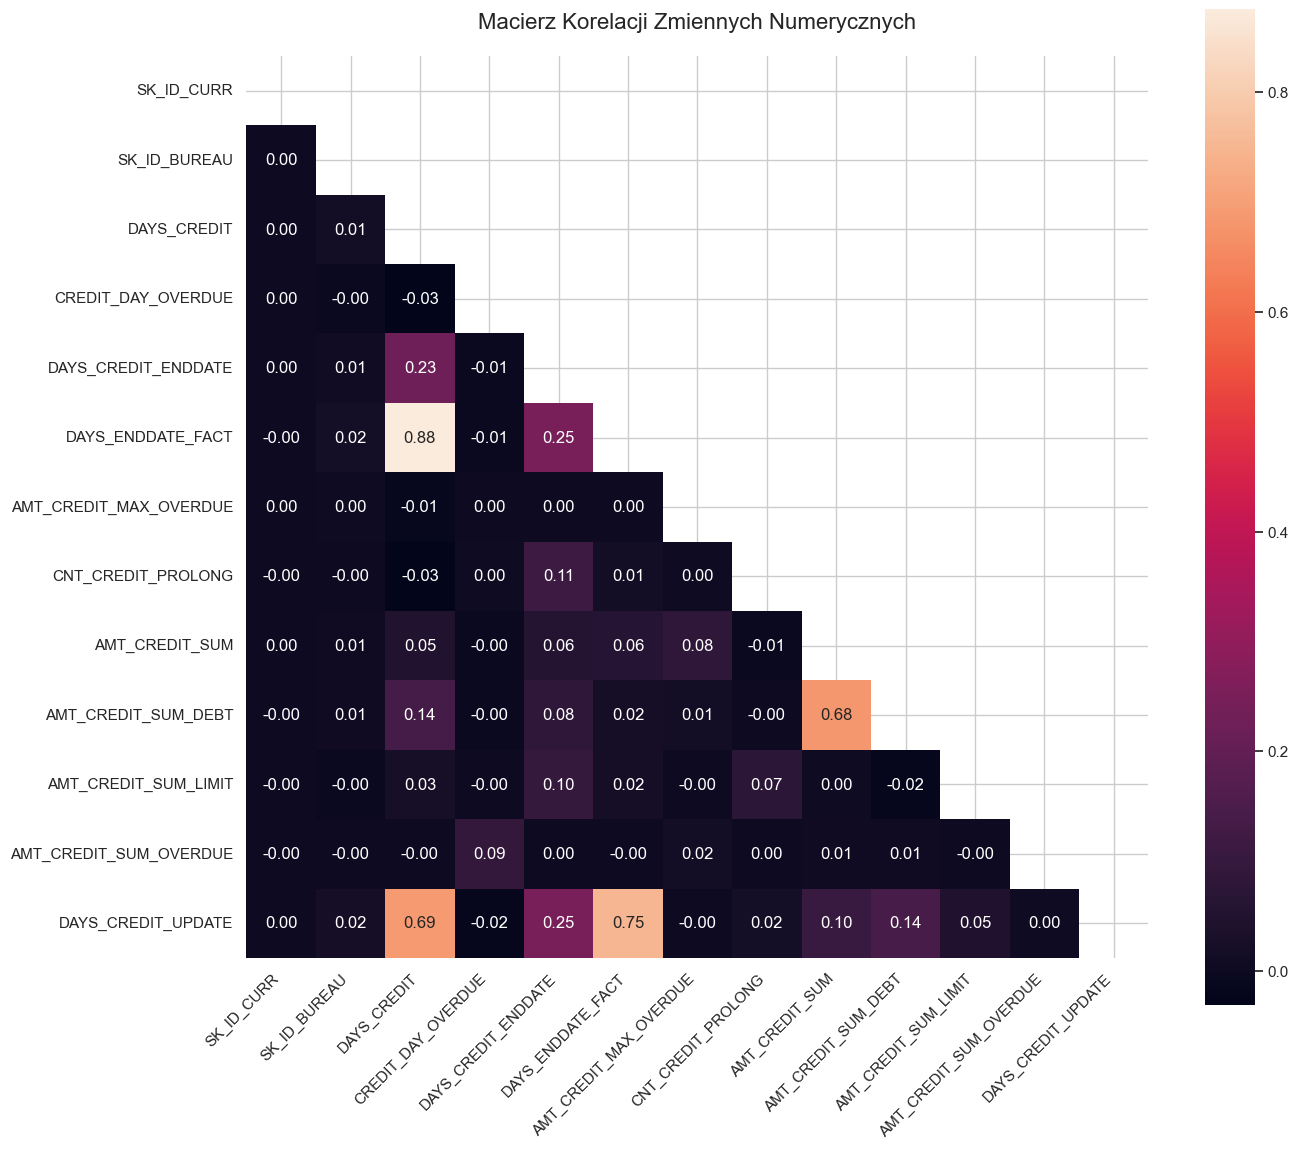

In [37]:
# Teraz zajmujemy się zmiennymi numerycznymi. Część z nich może być ze sobą mocno skorelowana więc tworzymy macierz korelacji
bureau_numerical=bureau.select_dtypes(exclude=['object'])

corr_matrix = bureau_numerical.corr()
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Rysowanie mapy cieplnej
sns.heatmap(corr_matrix, 
            mask=mask,              
            annot=True,              
            fmt=".2f",                           
            square=True,            
           )          
            

plt.title('Macierz Korelacji Zmiennych Numerycznych', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

In [38]:
# Widzimy że np zmienne AMT_CREDIT_SUM i AMT_CREDIT_SUM_DEBT są mocno skorelowane. Stwóz więc z nich jeden jedną cechę bedacą
# wskaźnikiem zadłużenia
bureau_numerical['DEBT_RATIO']=np.where(
    bureau_numerical['AMT_CREDIT_SUM'] > 0, 
    bureau_numerical['AMT_CREDIT_SUM_DEBT'] / bureau_numerical['AMT_CREDIT_SUM'], 
    np.nan)

In [39]:
# Tworzymy słownik dla agregatów konkretnych kolumn 
aggregations = {
    'DAYS_CREDIT': ['min', 'max'],                   # Kiedy klient brał kredyty
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],           # Opóźnienia w spłacie
    'AMT_CREDIT_MAX_OVERDUE': ['mean', 'max'],       # Maksymalna kwota zaległości
    'DEBT_RATIO': ['sum', 'mean', 'max'],            # Wskaźnik zadłużenia
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],   # Obecne zadłużenie
    'AMT_CREDIT_SUM_OVERDUE': ['sum', 'mean']        # Zaległości
}

# Agregacja i spłaszczenie indeksu
bureau_num_agg = bureau_numerical.groupby('SK_ID_CURR').agg(aggregations).reset_index()

# Pandas tworzy MultiIndex (np. poziom 1: 'DAYS_CREDIT', poziom 2: 'mean'). Spłaszczamy to do jednej nazwy.
bureau_num_agg.columns = ['SK_ID_CURR'] + [f'BUREAU_{col[0]}_{col[1].upper()}' for col in bureau_num_agg.columns[1:]]

In [40]:
# Dołączamy zagregowane dane numeryczne
df = df.merge(bureau_num_agg, on='SK_ID_CURR', how='left')
# Dołączamy zagregowane dane kategoryczne
df = df.merge(bureau_cat_agg, on='SK_ID_CURR', how='left')

## TABELKA bureau_balance

In [41]:
# Zliczenie ile łącznie miesięcy oraz jaki procent czasu dany kredyt był w danym statusie
bureau_balance_cat = pd.get_dummies(bureau_balance, columns=['STATUS'])
bureau_balance_aggregations = {}
for col in bureau_balance_cat.columns:
    if col.startswith('STATUS_'):
        bureau_balance_aggregations[col] = ['mean', 'sum']

bureau_balance_agg = bureau_balance_cat.groupby('SK_ID_BUREAU').agg(bureau_balance_aggregations).reset_index()

bureau_balance_agg.columns = ['SK_ID_BUREAU'] + [f'BUREAU_BALANCE_{col[0]}_{col[1].upper()}' for col in bureau_balance_agg.columns[1:]]

# Zliczenie ile miesięcy trwał dany kredyt
bureau_balance_months_count = bureau_balance.groupby('SK_ID_BUREAU').size().reset_index(name='BUREAU_BALANCE_MONTHS_COUNT')

bureau_balance_agg = bureau_balance_agg.merge(bureau_balance_months_count, on='SK_ID_BUREAU', how='left')

# Dołączamy naszą nową wiedzę o zachowaniu w czasie do głównej tabeli z historią
bureau_extended = bureau.merge(bureau_balance_agg, on='SK_ID_BUREAU', how='left')

In [42]:
# Mamy info o konkrentych kredytach to teraz będziemy chcieli je zagregować w tabeli Bureau po konkretnych klientach
bureau_balance_cols = [col for col in bureau_extended.columns if col.startswith('BUREAU_BALANCE_')]
bureau_balance_subset = bureau_extended[['SK_ID_CURR'] + bureau_balance_cols]

# Sprawdzamy zachowania klienta agregując dane po klientach
client_bureau_balance_agg = bureau_balance_subset.groupby('SK_ID_CURR').mean().reset_index()

# Zmieniamy nazwy, żeby w tabeli głównej wiedzieć, że to średnie dla klienta
client_bureau_balance_agg.columns = ['SK_ID_CURR'] + [f'CLIENT_{col}_MEAN' for col in client_bureau_balance_agg.columns if col != 'SK_ID_CURR']

# Dołączamy tabelkę zagregowaną po klientach do tabeli treningowej
df = df.merge(client_bureau_balance_agg, on='SK_ID_CURR', how='left')

## Tworzymy finalną tabelkę z zagregowanymi danymi per klient

In [43]:
df = df.merge(df2_agg, on='SK_ID_CURR', how='left')

In [44]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_max_max,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_mean_mean,credit_card_balance_CNT_INSTALMENT_MATURE_CUM_sum_sum,credit_card_balance_SK_DPD_min_min,credit_card_balance_SK_DPD_max_max,credit_card_balance_SK_DPD_mean_sum,credit_card_balance_SK_DPD_DEF_min_min,credit_card_balance_SK_DPD_DEF_max_max,credit_card_balance_SK_DPD_DEF_mean_sum,credit_card_balance_is_active_sum_sum
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0


In [45]:
text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    if set(df[col].dropna().unique()).issubset({"Y", "N"}):
        df[col] = df[col].map({"Y": 1, "N": 0})

In [46]:
text_cols = df.select_dtypes(include=["object", "string"]).columns
df = pd.get_dummies(df, columns=text_cols)
df.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,...,HOUSETYPE_MODE_terraced house,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,...,False,False,False,False,False,False,True,False,True,False
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,...,False,True,False,False,False,False,False,False,True,False
2,100004,0,1,1,0,67500.0,135000.0,6750.0,135000.0,0.010032,...,False,False,False,False,False,False,False,False,False,False
3,100006,0,0,1,0,135000.0,312682.5,29686.5,297000.0,0.008019,...,False,False,False,False,False,False,False,False,False,False
4,100007,0,0,1,0,121500.0,513000.0,21865.5,513000.0,0.028663,...,False,False,False,False,False,False,False,False,False,False


In [47]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype('int8')

In [48]:
threshold = 0.95
num_df = df.select_dtypes(include=['number'])
zero_fraction = (num_df == 0).sum() / len(df)
cols_to_drop = zero_fraction[zero_fraction > threshold].index
df = df.drop(columns=cols_to_drop)
print(len(cols_to_drop))

116


In [49]:
df.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,...,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Other,ORGANIZATION_TYPE_Self-employed,ORGANIZATION_TYPE_XNA,FONDKAPREMONT_MODE_reg oper account,HOUSETYPE_MODE_block of flats,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",EMERGENCYSTATE_MODE_No
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,...,1,1,0,0,0,1,1,0,1,1
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,...,0,0,0,0,0,1,1,0,0,1
2,100004,0,1,1,0,67500.0,135000.0,6750.0,135000.0,0.010032,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,1,0,135000.0,312682.5,29686.5,297000.0,0.008019,...,1,1,0,0,0,0,0,0,0,0
4,100007,0,0,1,0,121500.0,513000.0,21865.5,513000.0,0.028663,...,0,0,0,0,0,0,0,0,0,0


In [50]:
df = df.select_dtypes(include=['number'])
selector = VarianceThreshold(threshold=0.01)
df= df.loc[:, selector.fit(df).get_support()]

In [51]:
df.head()

,SK_ID_CURR,TARGET,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,...,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Other,ORGANIZATION_TYPE_Self-employed,ORGANIZATION_TYPE_XNA,FONDKAPREMONT_MODE_reg oper account,HOUSETYPE_MODE_block of flats,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",EMERGENCYSTATE_MODE_No
0,100002,1,0,1,0,202500.0,406597.5,24700.5,351000.0,-9461,...,1,1,0,0,0,1,1,0,1,1
1,100003,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,-16765,...,0,0,0,0,0,1,1,0,0,1
2,100004,0,1,1,0,67500.0,135000.0,6750.0,135000.0,-19046,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,1,0,135000.0,312682.5,29686.5,297000.0,-19005,...,1,1,0,0,0,0,0,0,0,0
4,100007,0,0,1,0,121500.0,513000.0,21865.5,513000.0,-19932,...,0,0,0,0,0,0,0,0,0,0


In [52]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"Columns with > 0% missing:\n{missing_pct[missing_pct > 20]}")

Columns with > 0% missing:
credit_card_balance_AMT_PAYMENT_CURRENT_mean_mean         82.816224
credit_card_balance_AMT_PAYMENT_CURRENT_min_min           82.816224
credit_card_balance_AMT_PAYMENT_CURRENT_max_max           82.816224
credit_card_balance_CNT_DRAWINGS_ATM_CURRENT_mean_mean    82.787608
credit_card_balance_AMT_DRAWINGS_POS_CURRENT_min_min      82.787608
                                                            ...    
FLOORSMAX_MODE                                            49.760822
FLOORSMAX_MEDI                                            49.760822
TOTALAREA_MODE                                            48.268517
BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX                         40.201814
BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN                        40.201814
Length: 70, dtype: float64


In [53]:
df_fill_na=df.fillna(-99999999999)

In [54]:
print(f"Shape after preprocessing: {df_fill_na.shape}")

Shape after preprocessing: (307511, 354)


## 4. Feature Selection

Select **15–20 features** using Boruta or Best Subset Selection.
This reduces dimensionality and improves interpretability of counterfactuals.

In [55]:
X = df_fill_na.drop(columns=['SK_ID_CURR','TARGET'])
y = df_fill_na['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_boruta_final, _, y_boruta_final, _ = train_test_split(
    X_train, y_train, 
    train_size=30000,       
    stratify=y_train,       
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators='auto',
    n_jobs=-1,
    max_depth=5,      
    random_state=42
)

boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    alpha=0.05,
    max_iter=50,       
    random_state=42
)

boruta_selector.fit(X_boruta_final.values, y_boruta_final.values)

confirmed_features = X_train.columns[boruta_selector.support_].tolist()


Iteration: 	1 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	2 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	3 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	4 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	5 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	6 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	7 / 50
Confirmed: 	0
Tentative: 	352
Rejected: 	0
Iteration: 	8 / 50
Confirmed: 	49
Tentative: 	47
Rejected: 	256
Iteration: 	9 / 50
Confirmed: 	49
Tentative: 	47
Rejected: 	256
Iteration: 	10 / 50
Confirmed: 	49
Tentative: 	47
Rejected: 	256
Iteration: 	11 / 50
Confirmed: 	49
Tentative: 	47
Rejected: 	256
Iteration: 	12 / 50
Confirmed: 	50
Tentative: 	38
Rejected: 	264
Iteration: 	13 / 50
Confirmed: 	50
Tentative: 	38
Rejected: 	264
Iteration: 	14 / 50
Confirmed: 	50
Tentative: 	38
Rejected: 	264
Iteration: 	15 / 50
Confirmed: 	50
Tentative: 	38
Rejected: 	264
Iteration: 	16 / 50
Confirmed: 	50
Tentative: 	2

In [56]:
rf_evaluator = RandomForestClassifier(
    n_estimators=100, 
    n_jobs=-1, 
    random_state=42
)
rf_evaluator.fit(X_train[confirmed_features], y_train)

importances = rf_evaluator.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': confirmed_features,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

top_20_features = feature_importance_df.head(20)['Feature'].tolist()

print("\n Wagi dla Top 20:")
print(feature_importance_df.head(20))


 Wagi dla Top 20:
                                             Feature  Importance
11                             EXTERNAL_SOURCES_MEAN    0.057167
6                                       EXT_SOURCE_2    0.041934
1                                         DAYS_BIRTH    0.031221
3                                  DAYS_REGISTRATION    0.030574
4                                    DAYS_ID_PUBLISH    0.030483
7                                       EXT_SOURCE_3    0.029586
2                                      DAYS_EMPLOYED    0.028235
43      installments_payments_AMT_INSTALMENT_max_max    0.026709
35  POS_CASH_balance_CNT_INSTALMENT_FUTURE_mean_mean    0.026349
44    installments_payments_AMT_INSTALMENT_mean_mean    0.026107
45      installments_payments_AMT_INSTALMENT_sum_sum    0.025596
14                            BUREAU_DAYS_CREDIT_MAX    0.025297
42      installments_payments_AMT_INSTALMENT_min_min    0.025047
10                               DAYS_EMPLOYED_RATIO    0.024817
13    

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [57]:
X = df[top_20_features]
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.4f}")
print(f"Test target rate:  {y_test.mean():.4f}")

Train: (246008, 20), Test: (61503, 20)
Train target rate: 0.0807
Test target rate:  0.0807


In [58]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

lgbm = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=10000,        
    learning_rate=0.01,        
    num_leaves=127,           
    max_depth=-1,             
    min_child_samples=30,      
    subsample=0.8,            
    colsample_bytree=0.8,
    max_bin=255,              
    class_weight='balanced',   
    importance_type='gain',  
    n_jobs=-1,
    random_state=42
)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
]

print("Rozpoczynam trening modelu...")


lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_metric='auc',                       
    callbacks=callbacks
)


best_iteration = lgbm.best_iteration_
val_auc = lgbm.best_score_['valid_1']['auc']

print(f"Osiągnięty wynik AUC na zbiorze walidacyjnym: {val_auc:.4f}")

Rozpoczynam trening modelu...
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023969 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5095
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[515]	training's auc: 0.853122	training's binary_logloss: 0.499087	valid_1's auc: 0.753697	valid_1's binary_logloss: 0.538127
Osiągnięty wynik AUC na zbiorze walidacyjnym: 0.7537


Wynik ROC AUC na zbiorze testowym: 0.7552


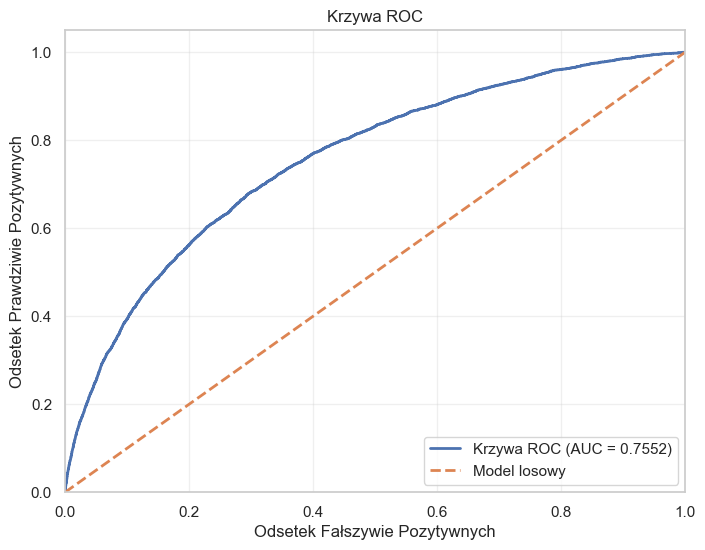

In [59]:
y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

# TODO: Print Roc AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Wynik ROC AUC na zbiorze testowym: {roc_auc:.4f}")

# TODO: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Rysowanie wykresu
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'Krzywa ROC (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], lw=2, linestyle='--', label='Model losowy')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Odsetek Fałszywie Pozytywnych')
plt.ylabel('Odsetek Prawdziwie Pozytywnych')
plt.title('Krzywa ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

   Rating  PD_lower  PD_upper
0     AAA    0.0000    0.0002
1     AA+    0.0002    0.0004
2      AA    0.0004    0.0008
3     AA-    0.0008    0.0015
4      A+    0.0015    0.0025
5       A    0.0025    0.0040
6      A-    0.0040    0.0060
7    BBB+    0.0060    0.0100
8     BBB    0.0100    0.0150
9    BBB-    0.0150    0.0250
10    BB+    0.0250    0.0400
11     BB    0.0400    0.0600
12    BB-    0.0600    0.1000
13     B+    0.1000    0.1500
14      B    0.1500    0.2000
15     B-    0.2000    0.3000
16    CCC    0.3000    0.4000
17     CC    0.4000    0.5000
18      C    0.5000    0.7000
19      D    0.7000    1.0000


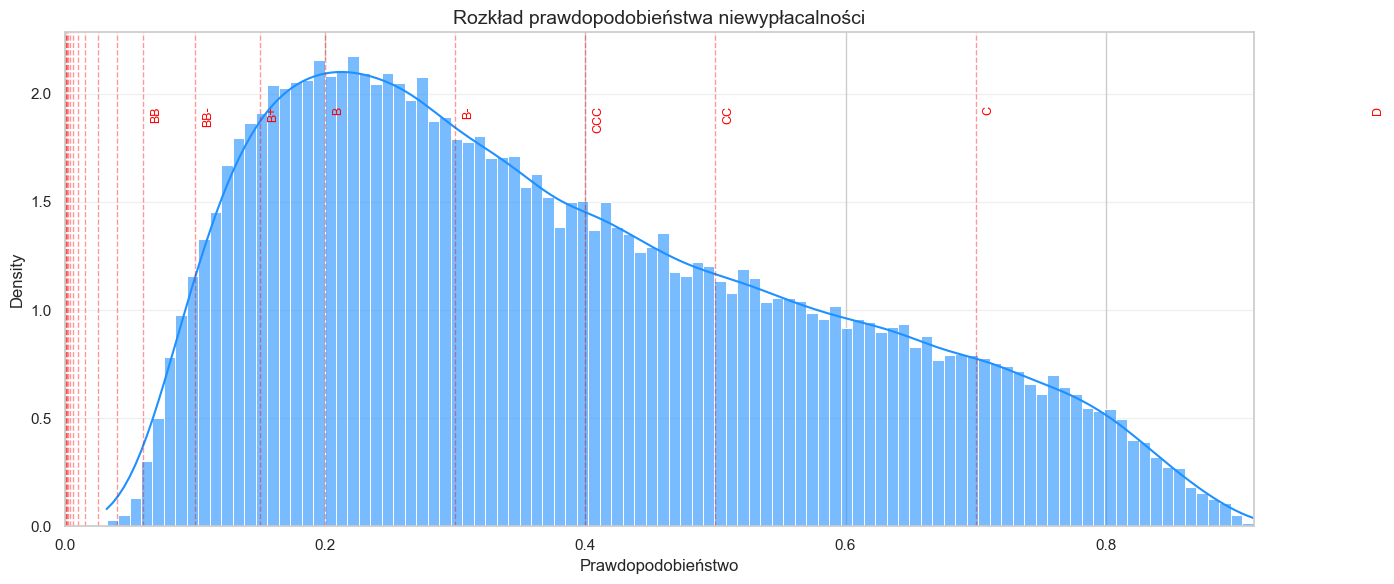

Wybrany próg decyzyjny: 0.5
Faktyczny odsetek portfela odrzucony jako 'bad': 28.78%


In [60]:
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})

print(masterscale)

y_pred_proba = lgbm.predict_proba(X_test)[:, 1]

plt.figure(figsize=(14, 6))

sns.histplot(y_pred_proba, bins=100, kde=True, color='dodgerblue', stat='density', alpha=0.6)

for idx, row in masterscale.iterrows():
    plt.axvline(x=row['PD_upper'], color='red', linestyle='--', alpha=0.4, linewidth=1)
    
    if row['PD_upper'] > 0.05: 
        plt.text(row['PD_upper'] + 0.005, plt.ylim()[1] * 0.85, row['Rating'], 
                 rotation=90, color='red', fontsize=9, verticalalignment='top')
        
plt.title('Rozkład prawdopodobieństwa niewypłacalności', fontsize=14)
plt.xlabel('Prawdopodobieństwo', fontsize=12)
plt.xlim(0, max(y_pred_proba.max(), 0.3))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

decision_threshold = None
selected_rating = None

for idx, row in masterscale.iloc[::-1].iterrows():
    threshold = row['PD_upper']
    
    # Sprawdzamy, jaki procent próbki testowej przekracza ten próg
    fraction_bad = np.mean(y_pred_proba >= threshold)
    
    if fraction_bad >= 0.10:
        decision_threshold = threshold
        selected_rating = row['Rating']
        break 

print(f"Wybrany próg decyzyjny: {decision_threshold}")
print(f"Faktyczny odsetek portfela odrzucony jako 'bad': {(np.mean(y_pred_proba >= decision_threshold) * 100):.2f}%")

Optymalny Próg: 0.6521
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.25      0.42      0.31      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.65      0.62     61503
weighted avg       0.89      0.85      0.87     61503



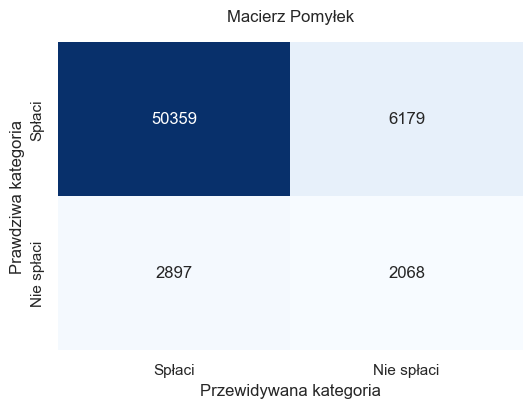

In [61]:
# TODO: Calculate the classification metrics

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                      out=np.zeros_like(precisions), where=(precisions + recalls) != 0)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]


y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print(f"Optymalny Próg: {optimal_threshold:.4f}")
print(classification_report(y_test, y_pred_optimal))

# Macierz błędów
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Spłaci', 'Nie spłaci'],
            yticklabels=['Spłaci', 'Nie spłaci'])
plt.title(f'Macierz Pomyłek', pad=15)
plt.ylabel('Prawdziwa kategoria')
plt.xlabel('Przewidywana kategoria')
plt.show()

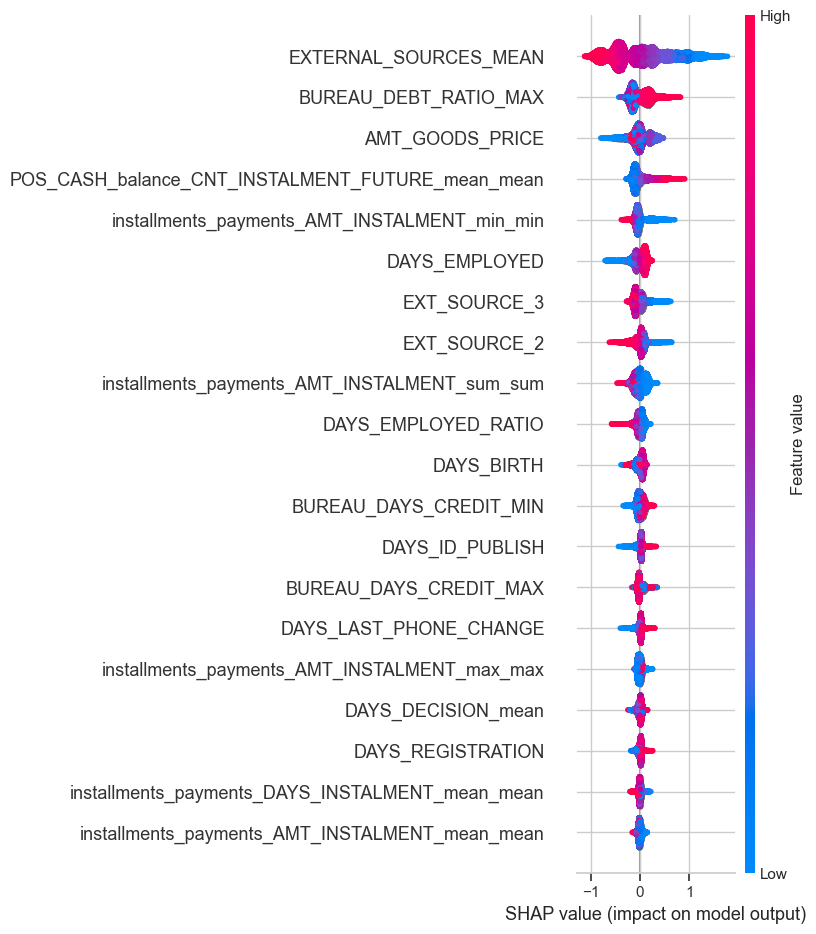

In [74]:
# TODO: Plot SHAP summary plot
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="dot")

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [62]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(lgbm, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == roc_auc
print("Model verification passed!")

Model saved to C:\Users\konra\wut-counterfactual-explanations\models\final_model.pkl
Model verification passed!


## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |